# Chapter 10: Big Entropy and the Generalized Linear Model

## Why This Chapter Matters

Every model so far assumed a **Gaussian likelihood**: outcomes are continuous and unbounded. But most interesting outcomes aren't:
- Did the patient survive? → 0 or 1
- How many tools does this island society have? → non-negative integer
- How many accidents occurred this month? → non-negative integer

Forcing a Gaussian on these produces nonsense predictions (e.g., negative counts, probabilities > 1). We need a principled way to choose the right distribution.

## Maximum Entropy: The Principled Distribution Picker

**The question**: given what we know about the outcome, which probability distribution should we use?

**The answer**: use the distribution with **maximum entropy** subject to your constraints — it is the least-informative distribution consistent with what you know. Any other choice smuggles in unjustified assumptions.

| Constraints you know | Maximum entropy distribution |
|---------------------|-----------------------------|
| Continuous, known mean & variance | Gaussian |
| Binary outcome (0/1), known N and p | Binomial |
| Non-negative integer, known mean rate | Poisson |
| Non-negative continuous | Exponential |

## The GLM Framework

A **Generalized Linear Model** has three parts:

1. **Distribution**: the likelihood for the outcome (Binomial, Poisson, …)
2. **Linear predictor**: `η = α + β₁x₁ + β₂x₂ + …`
3. **Link function** `f`: maps the linear predictor to the distribution's parameter
   - `f(μ) = η`  i.e.  `μ = f⁻¹(η)`

| Likelihood | Parameter | Link function | Inverse link |
|-----------|-----------|---------------|--------------|
| Binomial  | p ∈ (0,1) | logit: log(p/1−p) | logistic: 1/(1+e^−η) |
| Poisson   | λ > 0     | log: log(λ) | exp: e^η |
| Gaussian  | μ ∈ ℝ     | identity | identity |

**Critical implication**: parameters live on the *link scale*, not the outcome scale. A β of +2 in logistic regression is a +2 change in log-odds, not a +2 change in probability. Interpretation requires back-transforming.

---

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats, special

plt.style.use('default')
%matplotlib inline
rng = np.random.default_rng(42)

print(f'PyMC  {pm.__version__}  |  ArviZ {az.__version__}')

PyMC  5.26.1  |  ArviZ 0.22.0


## Maximum Entropy in Action

### The coin-flip analogy

Suppose you know an event happens with probability p = 0.7. Many distributions are consistent with that constraint. Which one to use?

**Entropy** of a discrete distribution: `H = -Σ pᵢ log(pᵢ)`  
Higher entropy = more spread out = fewer hidden assumptions.

The Binomial is the max-entropy distribution for binary events with a fixed expected value.

In [2]:
def entropy(p):
    """Shannon entropy of a discrete distribution (ignores zeros)."""
    p = np.array(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

# 5 candidate distributions over outcomes {0,1,2,3,4}, all with mean=1.4
# (following McElreath's pebble-bucket example)
candidates = {
    'A: [0.2, 0.2, 0.2, 0.2, 0.2]': [0.2,  0.2,  0.2,  0.2,  0.2 ],
    'B: [0.0, 0.1, 0.9, 0.0, 0.0]': [0.0,  0.1,  0.9,  0.0,  0.0 ],
    'C: [0.3, 0.3, 0.2, 0.1, 0.1]': [0.3,  0.3,  0.2,  0.1,  0.1 ],
    'D: [0.0, 0.7, 0.1, 0.1, 0.1]': [0.0,  0.7,  0.1,  0.1,  0.1 ],
    'E: binomial(4, 0.35)':          list(stats.binom.pmf(range(5), 4, 0.35)),
}

print(f'{"Distribution":<35} {"Mean":>6}  {"Entropy":>8}')
print('-' * 52)
for name, p in candidates.items():
    mean = sum(i * pi for i, pi in enumerate(p))
    h    = entropy(p)
    print(f'{name:<35} {mean:>6.2f}  {h:>8.4f}')

print()
print('Binomial has the highest entropy for a given mean — it is the flattest')
print('distribution consistent with the constraint.')

Distribution                          Mean   Entropy
----------------------------------------------------
A: [0.2, 0.2, 0.2, 0.2, 0.2]          2.00    1.6094
B: [0.0, 0.1, 0.9, 0.0, 0.0]          1.90    0.3251
C: [0.3, 0.3, 0.2, 0.1, 0.1]          1.40    1.5048
D: [0.0, 0.7, 0.1, 0.1, 0.1]          1.60    0.9404
E: binomial(4, 0.35)                  1.40    1.3458

Binomial has the highest entropy for a given mean — it is the flattest
distribution consistent with the constraint.


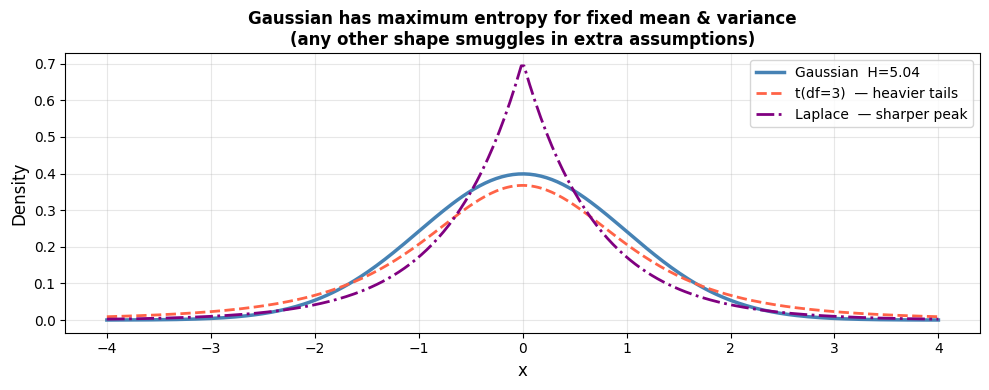

In [17]:
# Visualise: Gaussian maximises entropy for fixed mean & variance
x = np.linspace(-4, 4, 300)
mu, sigma = 0, 1

# Several distributions with mean=0, var=1
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, stats.norm.pdf(x, 0, 1),
        lw=2.5, color='steelblue', label=f'Gaussian  H={entropy(stats.norm.pdf(x,0,1)*(x[1]-x[0])):.2f}')
ax.plot(x, stats.t.pdf(x, df=3),
        lw=2, color='tomato',     ls='--', label='t(df=3)  — heavier tails')
ax.plot(x, stats.laplace.pdf(x, 0, 1/np.sqrt(2)),
        lw=2, color='purple',     ls='-.', label='Laplace  — sharper peak')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Gaussian has maximum entropy for fixed mean & variance\n'
             '(any other shape smuggles in extra assumptions)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## The Link Function: Why It Matters

### The logit link (Binomial regression)

Probability p lives in (0, 1). A linear predictor lives in (−∞, +∞). The **logit** maps p to the real line:

$$\text{logit}(p) = \log\frac{p}{1-p} = \alpha + \beta x$$

Inverse: $p = \text{logistic}(\eta) = \frac{1}{1 + e^{-\eta}}$

**Key consequence**: the effect of β on *probability* is **not constant** — it depends on where you are on the probability scale. A +1 change in log-odds near p=0.5 changes probability by ~0.25; near p=0.99 it changes probability by ~0.01.

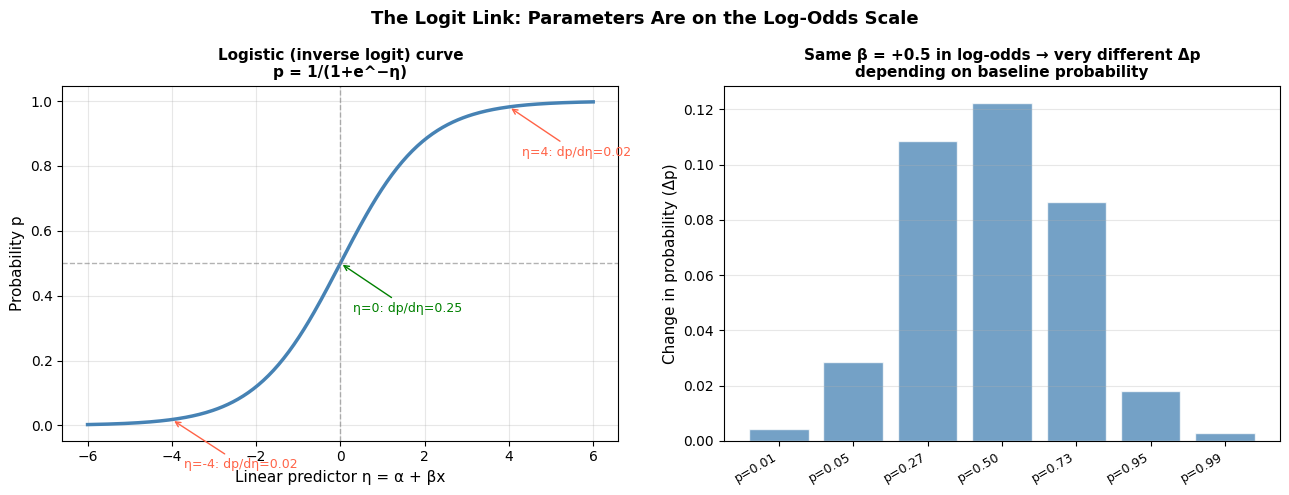

Same β = +0.5 change in log-odds produces very different Δp:
  p: 0.01 → 0.01   Δp = +0.004
  p: 0.05 → 0.08   Δp = +0.028
  p: 0.27 → 0.38   Δp = +0.109
  p: 0.50 → 0.62   Δp = +0.122
  p: 0.73 → 0.82   Δp = +0.087
  p: 0.95 → 0.97   Δp = +0.018
  p: 0.99 → 1.00   Δp = +0.003


In [4]:
eta = np.linspace(-6, 6, 300)
p   = special.expit(eta)   # logistic function = inverse logit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: logistic curve
ax = axes[0]
ax.plot(eta, p, lw=2.5, color='steelblue')
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax.axvline(0.0, color='gray', ls='--', lw=1, alpha=0.6)
# Annotate slope at different points
for eta0, color in [(-4, 'tomato'), (0, 'green'), (4, 'tomato')]:
    p0   = special.expit(eta0)
    dpde = p0 * (1 - p0)   # derivative of logistic
    ax.annotate(f'η={eta0}: dp/dη={dpde:.2f}',
                xy=(eta0, p0), xytext=(eta0 + 0.3, p0 - 0.15),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color))
ax.set_xlabel('Linear predictor η = α + βx', fontsize=11)
ax.set_ylabel('Probability p', fontsize=11)
ax.set_title('Logistic (inverse logit) curve\np = 1/(1+e^−η)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: effect of same β at different baseline probabilities
ax = axes[1]
beta = 0.5
baselines = np.array([-5, -3, -1, 0, 1, 3, 5])  # log-odds baseline
p_before = special.expit(baselines)
p_after  = special.expit(baselines + beta)
delta_p  = p_after - p_before

bars = ax.bar(range(len(baselines)), delta_p, color='steelblue', alpha=0.75, edgecolor='white')
ax.set_xticks(range(len(baselines)))
ax.set_xticklabels([f'p={pb:.2f}' for pb in p_before], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Change in probability (Δp)', fontsize=11)
ax.set_title(f'Same β = +{beta} in log-odds → very different Δp\ndepending on baseline probability',
             fontsize=11, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('The Logit Link: Parameters Are on the Log-Odds Scale',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Same β = +0.5 change in log-odds produces very different Δp:')
for pb, pa, dp in zip(p_before, p_after, delta_p):
    print(f'  p: {pb:.2f} → {pa:.2f}   Δp = {dp:+.3f}')

## Part 1: Binomial Regression (Logistic Regression)

### UCB Admissions — Aggregated binomial

Classic dataset: graduate admissions at UC Berkeley by department and gender. The question: is there a gender bias in admissions?

We model the number admitted out of applicants as Binomial:
$$A_i \sim \text{Binomial}(N_i, p_i)$$
$$\text{logit}(p_i) = \alpha_{\text{dept}[i]}$$

Starting with dept-only model, then adding gender.

In [5]:
# UCB Admissions data
ucb = pd.DataFrame({
    'dept':     ['A','A','B','B','C','C','D','D','E','E','F','F'],
    'gender':   ['M','F','M','F','M','F','M','F','M','F','M','F'],
    'admit':    [512, 89, 353, 17, 120,202, 138,131,  53, 94,  22, 24],
    'reject':   [313, 19, 207,  8, 205,391, 279,244, 138,299, 351,317],
})
ucb['applications'] = ucb['admit'] + ucb['reject']
ucb['admit_rate']   = ucb['admit'] / ucb['applications']
ucb['dept_id']      = pd.Categorical(ucb['dept']).codes
ucb['gender_id']    = (ucb['gender'] == 'M').astype(int)  # 1=Male, 0=Female

print(ucb[['dept','gender','admit','applications','admit_rate']].to_string(index=False))
print()
overall_m = ucb[ucb['gender']=='M']['admit'].sum() / ucb[ucb['gender']=='M']['applications'].sum()
overall_f = ucb[ucb['gender']=='F']['admit'].sum() / ucb[ucb['gender']=='F']['applications'].sum()
print(f'Overall admit rate — Male: {overall_m:.1%},  Female: {overall_f:.1%}')
print('(Raw rates suggest males are admitted more — but is that the full story?)')

dept gender  admit  applications  admit_rate
   A      M    512           825    0.620606
   A      F     89           108    0.824074
   B      M    353           560    0.630357
   B      F     17            25    0.680000
   C      M    120           325    0.369231
   C      F    202           593    0.340641
   D      M    138           417    0.330935
   D      F    131           375    0.349333
   E      M     53           191    0.277487
   E      F     94           393    0.239186
   F      M     22           373    0.058981
   F      F     24           341    0.070381

Overall admit rate — Male: 44.5%,  Female: 30.4%
(Raw rates suggest males are admitted more — but is that the full story?)


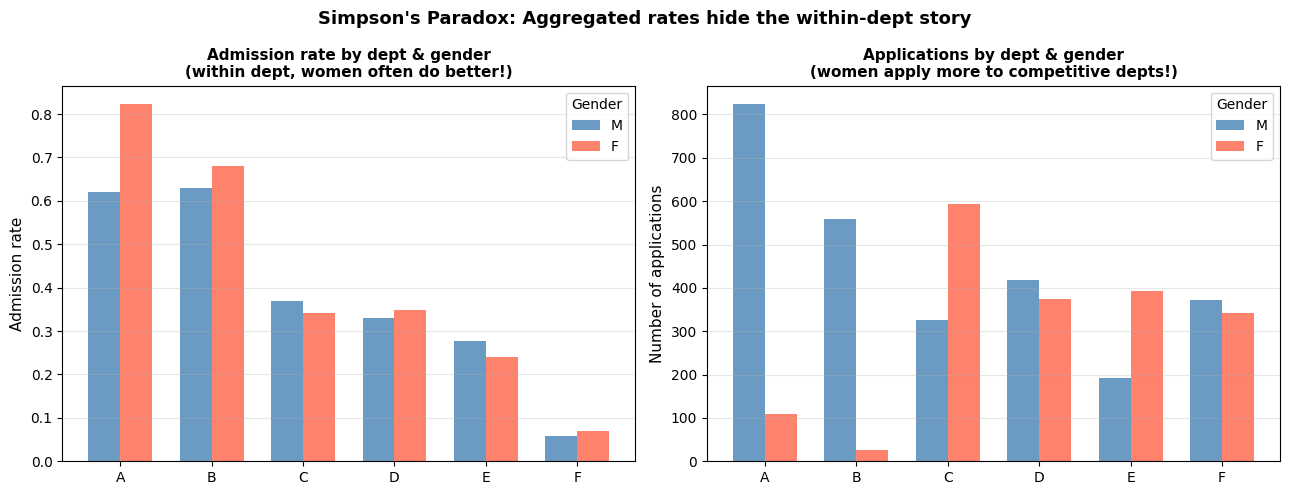

In [6]:
# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: admission rates by dept and gender
ax = axes[0]
depts = ucb['dept'].unique()
x = np.arange(len(depts))
width = 0.35
for i, (gender, color) in enumerate([('M', 'steelblue'), ('F', 'tomato')]):
    rates = ucb[ucb['gender']==gender].set_index('dept')['admit_rate'][depts]
    ax.bar(x + i*width, rates, width, label=gender, color=color, alpha=0.8)
ax.set_xticks(x + width/2)
ax.set_xticklabels(depts)
ax.set_ylabel('Admission rate', fontsize=11)
ax.set_title('Admission rate by dept & gender\n(within dept, women often do better!)',
             fontsize=11, fontweight='bold')
ax.legend(title='Gender')
ax.grid(True, axis='y', alpha=0.3)

# Panel 2: applications by dept and gender (confound!)
ax = axes[1]
for i, (gender, color) in enumerate([('M', 'steelblue'), ('F', 'tomato')]):
    apps = ucb[ucb['gender']==gender].set_index('dept')['applications'][depts]
    ax.bar(x + i*width, apps, width, label=gender, color=color, alpha=0.8)
ax.set_xticks(x + width/2)
ax.set_xticklabels(depts)
ax.set_ylabel('Number of applications', fontsize=11)
ax.set_title('Applications by dept & gender\n(women apply more to competitive depts!)',
             fontsize=11, fontweight='bold')
ax.legend(title='Gender')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle("Simpson's Paradox: Aggregated rates hide the within-dept story",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model 1: Gender only (ignores dept)

In [7]:
admit    = ucb['admit'].values
apps     = ucb['applications'].values
gender_id = ucb['gender_id'].values   # 1=Male, 0=Female
dept_id   = ucb['dept_id'].values
n_depts   = ucb['dept_id'].nunique()

coords_ucb = {'gender': ['Female', 'Male'], 'dept': list('ABCDEF')}

# m_gender: log-odds of admission depends only on gender
# logit(p_i) = alpha[gender_i]
with pm.Model(coords=coords_ucb) as m_gender:
    alpha = pm.Normal('alpha', mu=0, sigma=1.5, dims='gender')
    p     = pm.Deterministic('p', pm.math.invlogit(alpha[gender_id]))
    admit_obs = pm.Binomial('admit_obs', n=apps, p=p, observed=admit)

    idata_gender = pm.sample(1000, tune=1000, chains=4,
                             target_accept=0.9, random_seed=42, progressbar=True)
    pm.compute_log_likelihood(idata_gender)

print(az.summary(idata_gender, var_names=['alpha'], hdi_prob=0.89).to_string())
print()

# Convert log-odds to probability scale
alpha_post = idata_gender.posterior['alpha']
for i, g in enumerate(['Female', 'Male']):
    log_odds = alpha_post.sel(gender=g).values.flatten()
    prob     = special.expit(log_odds)
    print(f'{g}: log-odds = {log_odds.mean():.2f},  p = {prob.mean():.2f}  '
          f'89% CI [{np.percentile(prob,5.5):.2f}, {np.percentile(prob,94.5):.2f}]')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

                mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha[Female] -0.829  0.049    -0.905     -0.749      0.001    0.001    4045.0    2493.0    1.0
alpha[Male]   -0.221  0.039    -0.286     -0.164      0.001    0.001    4091.0    2775.0    1.0

Female: log-odds = -0.83,  p = 0.30  89% CI [0.29, 0.32]
Male: log-odds = -0.22,  p = 0.45  89% CI [0.43, 0.46]


### Model 2: Department + Gender (the right model)

Condition on department to close the confound. Now `alpha[dept]` captures department difficulty and `beta[gender]` captures the *within-department* gender effect.

In [8]:
# m_dept_gender: logit(p_i) = alpha[dept_i] + beta[gender_i]
with pm.Model(coords=coords_ucb) as m_dept_gender:
    alpha = pm.Normal('alpha', mu=0, sigma=1.5, dims='dept')
    beta  = pm.Normal('beta',  mu=0, sigma=1.0, dims='gender')
    logit_p  = alpha[dept_id] + beta[gender_id]
    p        = pm.Deterministic('p', pm.math.invlogit(logit_p))
    admit_obs = pm.Binomial('admit_obs', n=apps, p=p, observed=admit)

    idata_dept = pm.sample(1000, tune=1000, chains=4,
                           target_accept=0.9, random_seed=42, progressbar=True)
    pm.compute_log_likelihood(idata_dept)

print(az.summary(idata_dept, var_names=['alpha', 'beta'], hdi_prob=0.89).to_string())
print()

# Gender effect on probability scale
beta_post = idata_dept.posterior['beta'].values.reshape(-1, 2)
# contrast: Male - Female in log-odds
diff_logodds = beta_post[:, 1] - beta_post[:, 0]
lo, hi = np.percentile(diff_logodds, [5.5, 94.5])
print(f'Gender contrast (Male − Female) in log-odds:')
print(f'  Mean = {diff_logodds.mean():+.3f},  89% CI = [{lo:+.3f}, {hi:+.3f}]')
print(f'  P(Male advantage) = {(diff_logodds > 0).mean():.1%}')
print()
print('Within departments, the gender effect is much smaller / reversed!')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

               mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha[A]      1.020  0.470     0.268      1.788      0.021    0.014     506.0     696.0   1.01
alpha[B]      0.974  0.473     0.139      1.667      0.021    0.014     513.0     683.0   1.01
alpha[C]     -0.244  0.469    -0.986      0.511      0.021    0.014     506.0     640.0   1.01
alpha[D]     -0.275  0.469    -1.056      0.455      0.021    0.014     505.0     696.0   1.01
alpha[E]     -0.717  0.474    -1.474      0.050      0.021    0.014     507.0     679.0   1.01
alpha[F]     -2.276  0.480    -3.063     -1.526      0.021    0.013     524.0     802.0   1.00
beta[Female] -0.339  0.467    -1.061      0.435      0.021    0.014     503.0     626.0   1.01
beta[Male]   -0.438  0.467    -1.155      0.349      0.021    0.014     499.0     655.0   1.01

Gender contrast (Male − Female) in log-odds:
  Mean = -0.099,  89% CI = [-0.226, +0.033]
  P(Male advantage) = 11.4%

Within departments, the ge

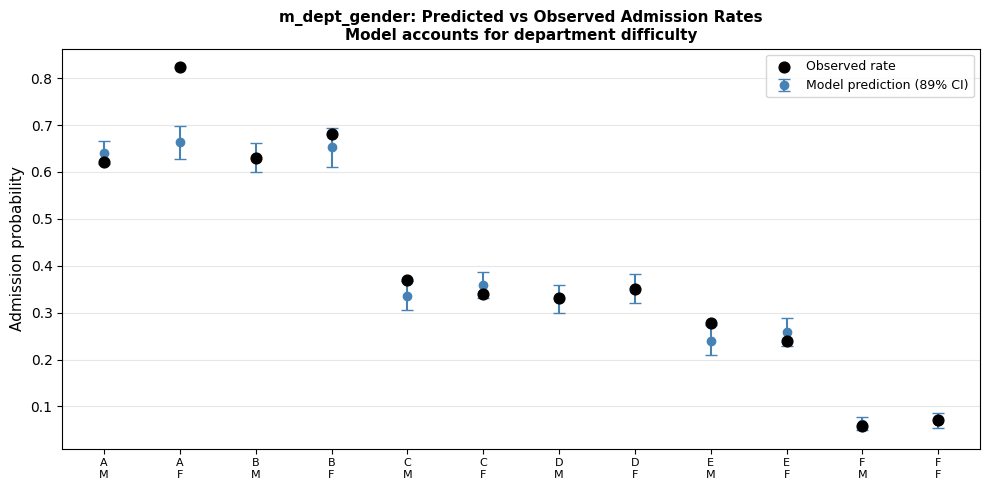

In [9]:
# Visualise: predicted admission rates vs observed
p_post = idata_dept.posterior['p'].values.reshape(-1, len(admit))  # (S, 12)
p_mean = p_post.mean(0)
p_lo   = np.percentile(p_post, 5.5,  axis=0)
p_hi   = np.percentile(p_post, 94.5, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
obs_rate = admit / apps
ax.errorbar(range(len(admit)), p_mean,
            yerr=[p_mean - p_lo, p_hi - p_mean],
            fmt='o', ms=6, color='steelblue', ecolor='steelblue',
            capsize=4, lw=1.5, label='Model prediction (89% CI)')
ax.scatter(range(len(admit)), obs_rate,
           s=60, color='black', zorder=4, label='Observed rate')

labels = [f'{d}\n{g[0]}' for d, g in zip(ucb['dept'], ucb['gender'])]
ax.set_xticks(range(len(admit)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Admission probability', fontsize=11)
ax.set_title('m_dept_gender: Predicted vs Observed Admission Rates\n'
             'Model accounts for department difficulty', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Poisson Regression

### When to use Poisson

Use Poisson when the outcome is a **count** that is (in principle) unbounded:
- Number of tools a society has
- Number of accidents per month  
- Number of papers published per year

$$y_i \sim \text{Poisson}(\lambda_i)$$
$$\log(\lambda_i) = \alpha + \beta x_i$$

The **log link** ensures λ > 0 (counts can't be negative). Coefficients are on the log-rate scale:
- β = +1 → predictor multiplies the rate by e¹ ≈ 2.7×
- β = +0.5 → rate multiplied by e⁰·⁵ ≈ 1.65×

### Oceanic tools dataset

10 Pacific island societies. How does the number of tool types relate to population size and contact with other islands?

In [10]:
url = 'https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Kline.csv'
kline = pd.read_csv(url, sep=';')
print(kline)
print()

# Standardise log population
kline['log_pop']     = np.log(kline['population'])
kline['log_pop_std'] = (kline['log_pop'] - kline['log_pop'].mean()) / kline['log_pop'].std()
kline['contact_id']  = (kline['contact'] == 'high').astype(int)  # 0=low, 1=high

tools      = kline['total_tools'].values
log_pop_s  = kline['log_pop_std'].values
contact_id = kline['contact_id'].values

print(kline[['culture','total_tools','population','log_pop_std','contact']].to_string(index=False))

      culture  population contact  total_tools  mean_TU
0    Malekula        1100     low           13      3.2
1     Tikopia        1500     low           22      4.7
2  Santa Cruz        3600     low           24      4.0
3         Yap        4791    high           43      5.0
4    Lau Fiji        7400    high           33      5.0
5   Trobriand        8000    high           19      4.0
6       Chuuk        9200    high           40      3.8
7       Manus       13000     low           28      6.6
8       Tonga       17500    high           55      5.4
9      Hawaii      275000     low           71      6.6

   culture  total_tools  population  log_pop_std contact
  Malekula           13        1100    -1.291473     low
   Tikopia           22        1500    -1.088551     low
Santa Cruz           24        3600    -0.515765     low
       Yap           43        4791    -0.328773    high
  Lau Fiji           33        7400    -0.044339    high
 Trobriand           19        8000     0

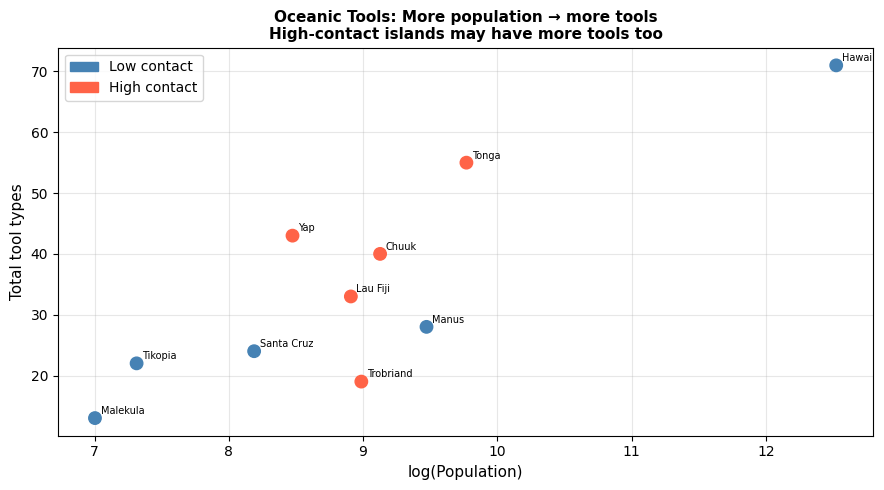

In [11]:
# Quick look
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if c == 'low' else 'tomato' for c in kline['contact']]
ax.scatter(kline['log_pop'], kline['total_tools'], s=80, c=colors, zorder=3)
for _, row in kline.iterrows():
    ax.annotate(row['culture'], (row['log_pop'], row['total_tools']),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Low contact'),
                   Patch(color='tomato',    label='High contact')])
ax.set_xlabel('log(Population)', fontsize=11)
ax.set_ylabel('Total tool types', fontsize=11)
ax.set_title('Oceanic Tools: More population → more tools\nHigh-contact islands may have more tools too',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Poisson model: tools ~ population + contact

In [12]:
# Prior check: what does alpha ~ Normal(3, 0.5) imply for lambda?
# log(lambda) = alpha  →  lambda = exp(alpha)
a_samples = rng.normal(3, 0.5, 1000)
lambda_samples = np.exp(a_samples)
print('Prior predictive check for alpha ~ Normal(3, 0.5):')
print(f'  E[lambda] = {lambda_samples.mean():.1f} tools  (mean tool count at mean population)')
print(f'  50% of prior mass: [{np.percentile(lambda_samples,25):.0f}, {np.percentile(lambda_samples,75):.0f}] tools')
print(f'  Observed range: [{tools.min()}, {tools.max()}] tools — prior is reasonable')

Prior predictive check for alpha ~ Normal(3, 0.5):
  E[lambda] = 22.4 tools  (mean tool count at mean population)
  50% of prior mass: [14, 27] tools
  Observed range: [13, 71] tools — prior is reasonable


In [13]:
coords_kline = {'contact': ['low', 'high']}

# log(lambda_i) = alpha[contact_i] + beta * log_pop_std_i
with pm.Model(coords=coords_kline) as m_tools:
    alpha   = pm.Normal('alpha', mu=3,   sigma=0.5, dims='contact')
    beta    = pm.Normal('beta',  mu=0,   sigma=0.2)
    log_lam = alpha[contact_id] + beta * log_pop_s
    lam     = pm.Deterministic('lambda', pm.math.exp(log_lam))
    obs     = pm.Poisson('obs', mu=lam, observed=tools)

    idata_tools = pm.sample(1000, tune=1000, chains=4,
                            target_accept=0.9, random_seed=42, progressbar=True)
    pm.compute_log_likelihood(idata_tools)

print(az.summary(idata_tools, var_names=['alpha', 'beta'], hdi_prob=0.89).to_string())
print()

# Interpret beta on the rate scale
beta_s = idata_tools.posterior['beta'].values.flatten()
rate_multiplier = np.exp(beta_s)
lo, hi = np.percentile(rate_multiplier, [5.5, 94.5])
print(f'beta = {beta_s.mean():.3f}  →  rate multiplier e^beta = {rate_multiplier.mean():.2f}')
print(f'  89% CI: [{lo:.2f}, {hi:.2f}]')
print(f'  1 SD increase in log population multiplies tool count by ~{rate_multiplier.mean():.2f}x')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/rich/li
ve.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

              mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha[low]   3.317  0.086     3.185      3.462      0.002    0.001    3030.0    3226.0    1.0
alpha[high]  3.596  0.073     3.478      3.712      0.001    0.001    3073.0    2654.0    1.0
beta         0.383  0.051     0.306      0.468      0.001    0.001    2812.0    2714.0    1.0

beta = 0.383  →  rate multiplier e^beta = 1.47
  89% CI: [1.35, 1.59]
  1 SD increase in log population multiplies tool count by ~1.47x


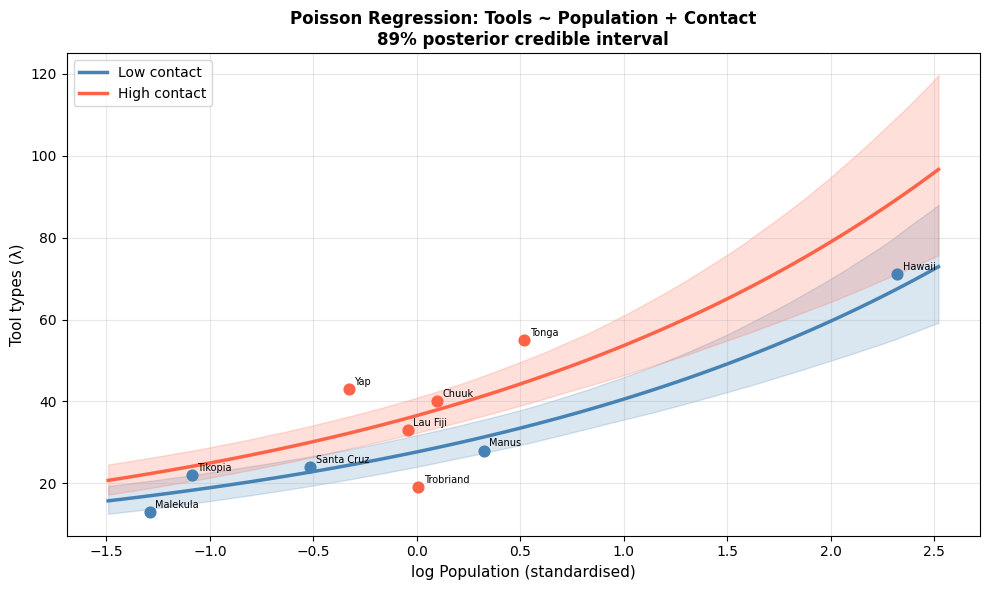

In [14]:
# Posterior predictions
lp_seq = np.linspace(log_pop_s.min() - 0.2, log_pop_s.max() + 0.2, 100)
post   = idata_tools.posterior
alpha_s = post['alpha'].values.reshape(-1, 2)   # (S, 2)
beta_s  = post['beta'].values.flatten()          # (S,)

fig, ax = plt.subplots(figsize=(10, 6))

for cid_val, color, label in [(0, 'steelblue', 'Low contact'), (1, 'tomato', 'High contact')]:
    lam_mat = np.exp(alpha_s[:, cid_val, None] + beta_s[:, None] * lp_seq[None, :])
    lam_mean = lam_mat.mean(0)
    lam_lo   = np.percentile(lam_mat, 5.5,  axis=0)
    lam_hi   = np.percentile(lam_mat, 94.5, axis=0)
    ax.fill_between(lp_seq, lam_lo, lam_hi, alpha=0.2, color=color)
    ax.plot(lp_seq, lam_mean, color=color, lw=2.5, label=label)

    mask = contact_id == cid_val
    ax.scatter(log_pop_s[mask], tools[mask], s=60, color=color, zorder=3)
    for i in np.where(mask)[0]:
        ax.annotate(kline.iloc[i]['culture'], (log_pop_s[i], tools[i]),
                    fontsize=7, xytext=(4, 3), textcoords='offset points')

ax.set_xlabel('log Population (standardised)', fontsize=11)
ax.set_ylabel('Tool types (λ)', fontsize=11)
ax.set_title('Poisson Regression: Tools ~ Population + Contact\n89% posterior credible interval',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Priors on the Link Scale

A common mistake: using `Normal(0, 10)` priors because they seem "vague." On the link scale they are wildly uninformative.

**Logit scale**: `Normal(0, 10)` puts most probability near p = 0 or p = 1 — basically saying "I think extreme probabilities are most likely," which is rarely sensible.

**Log scale**: `Normal(0, 10)` allows λ values up to e¹⁰ ≈ 22,000 — completely implausible for most count outcomes.

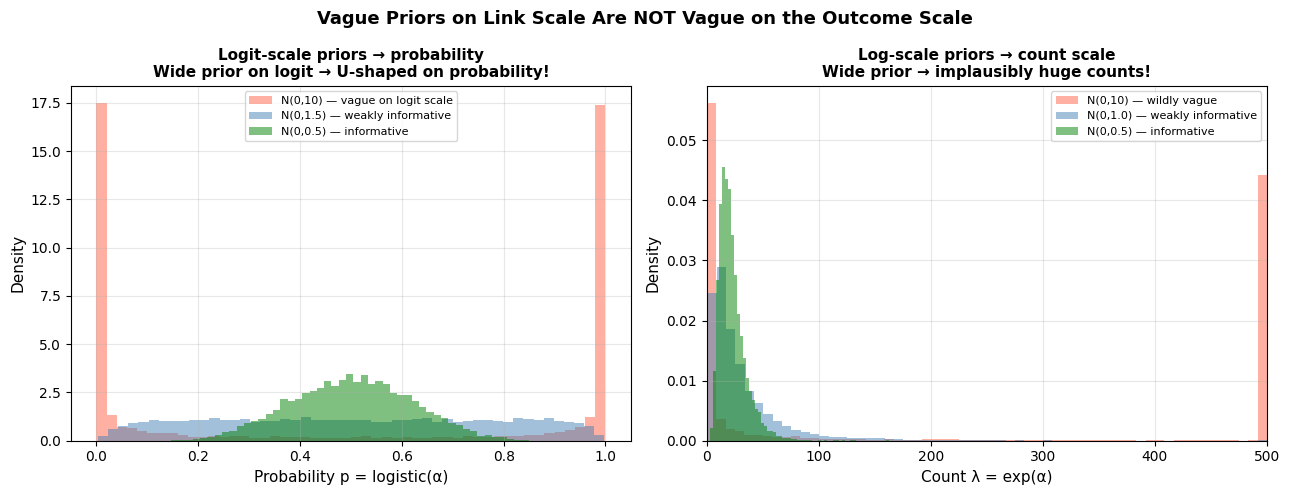

Rule of thumb for weakly informative priors:
  Logistic regression: α, β ~ Normal(0, 1.5)  — keeps probability away from 0/1
  Poisson regression:  α ~ Normal(log(mean), 0.5),  β ~ Normal(0, 0.2)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: logit scale prior → probability ─────────────────────────────────
ax = axes[0]
for sigma, color, label in [(10, 'tomato', 'N(0,10) — vague on logit scale'),
                             (1.5, 'steelblue', 'N(0,1.5) — weakly informative'),
                             (0.5, 'green',     'N(0,0.5) — informative')]:
    logit_samples = rng.normal(0, sigma, 10_000)
    p_samples     = special.expit(logit_samples)
    ax.hist(p_samples, bins=50, alpha=0.5, density=True, color=color, label=label)
ax.set_xlabel('Probability p = logistic(α)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Logit-scale priors → probability\nWide prior on logit → U-shaped on probability!',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: log scale prior → count ─────────────────────────────────────────
ax = axes[1]
for sigma, color, label in [(10,  'tomato',    'N(0,10) — wildly vague'),
                             (1.0, 'steelblue', 'N(0,1.0) — weakly informative'),
                             (0.5, 'green',     'N(0,0.5) — informative')]:
    log_lam = rng.normal(3, sigma, 10_000)   # mu=3 → lambda≈20 at baseline
    lam     = np.exp(log_lam)
    lam_clipped = np.clip(lam, 0, 500)
    ax.hist(lam_clipped, bins=60, alpha=0.5, density=True, color=color, label=label)
ax.set_xlabel('Count λ = exp(α)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Log-scale priors → count scale\nWide prior → implausibly huge counts!',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 500)
ax.grid(True, alpha=0.3)

plt.suptitle('Vague Priors on Link Scale Are NOT Vague on the Outcome Scale',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Rule of thumb for weakly informative priors:')
print('  Logistic regression: α, β ~ Normal(0, 1.5)  — keeps probability away from 0/1')
print('  Poisson regression:  α ~ Normal(log(mean), 0.5),  β ~ Normal(0, 0.2)')

## Key Insights

### 1. Maximum entropy justifies the distribution choice
Use the distribution that is maximally uncertain given your constraints:
- Binary / bounded count → Binomial (logit link)
- Unbounded count → Poisson (log link)
- Continuous, unbounded → Gaussian (identity link)

### 2. Parameters live on the link scale — always back-transform
- Logistic regression β = +1: one-unit increase in x → +1 change in *log-odds*, not probability
- Poisson β = +0.3: one-unit increase in x → e^0.3 ≈ 1.35× rate multiplier
- Always compute contrasts and predictions on the *probability/rate* scale for interpretation

### 3. Priors must be calibrated on the link scale
`Normal(0, 10)` looks flat but implies extreme probabilities (near 0 or 1) for logistic, or astronomically large rates for Poisson. Weakly informative defaults:
- Logistic: `Normal(0, 1.5)` for intercepts/slopes
- Poisson: `Normal(log(expected_count), 0.5)` for intercepts, `Normal(0, 0.2)` for slopes

### 4. GLMs extend naturally in PyMC
The swap from Gaussian to Binomial/Poisson is just:
- Change the likelihood distribution
- Change the link function (logit/log instead of identity)
- Everything else (priors, sampling, `az.summary`, `az.compare`) stays the same

### 5. Simpson's paradox (UCB)
Aggregated rates can reverse direction when you condition on a confounder (department). Always check the DAG before reporting results.

---

*Chapter 10 — Statistical Rethinking (McElreath, 2nd ed.)*